# Appendix A: Do Japan's prefectures form distinct industrial types?

Each prefecture is a vector of 24 industry employment shares. If regional
industrial structure is genuinely typed, similar prefectures should form natural
groups in that space.

**This notebook is built to be able to say no.** With 47 objects in 24 dimensions,
clustering always returns clusters — the algorithm has no way to report "there is no
structure here". Three safeguards decide the verdict, and they are applied before any
interpretation:

| Safeguard | What it rules out |
|---|---|
| Silhouette across k = 2..8 | Cherry-picking the flattering k |
| Permuted null | Structure that random data would also produce |
| Year-to-year adjusted Rand index | A partition that reshuffles every year |
| k-means vs Ward agreement | A partition that is an artefact of one algorithm |

### Why the shares must be transformed first

Employment shares sum to 1, so they are **compositional**: they lie on a simplex, not
in ordinary Euclidean space. Raising one share necessarily lowers the others, so
distances between raw share vectors are distorted by the constraint rather than by
real dissimilarity.

The standard remedy is the **centred log-ratio (CLR)** transform, dividing each
component by the geometric mean of the vector and taking logs. That maps the simplex
into real space where Euclidean distance behaves. Zeros need a small multiplicative
replacement first, since log(0) is undefined.

Skipping this step is a common and quiet error — the clustering still runs, and the
answer is still wrong.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJ / "src"))

from viz_style import (apply_style, subtitle, source_note, ROMAJI, INDUSTRY_EN,
                       BLUE, ORANGE, GRAY_MARK, INK, INK_SECONDARY, AXIS, SURFACE)
from cluster_typology import (analyse, share_matrix, clr, reduce_dims,
                              cluster_labels, K_RANGE)

apply_style()
OUT = PROJ / "outputs" / "charts"; OUT.mkdir(parents=True, exist_ok=True)

rep = analyse(n_null=200)
print(f"PCA retained {rep['pca_components']} components covering "
      f"{rep['pca_variance_explained']:.1%} of variance")
print(f"zero replacement value: {rep['zero_replacement_value']:.3e}")

PCA retained 7 components covering 80.2% of variance
zero replacement value: 5.491e-05


## How many clusters, and is any of it real?

In [2]:
prof = pd.DataFrame(rep["silhouette_profile"])
display(prof.rename(columns={
    "silhouette_kmeans": "silhouette (k-means)",
    "silhouette_ward": "silhouette (Ward)",
    "agreement_ari": "k-means vs Ward (ARI)"}).round(4).set_index("k"))

print(f"best k = {rep['k_best']}, silhouette {rep['silhouette_best']:.4f}")
print(f"permuted null ({rep['null_iterations']} iterations): "
      f"mean {rep['null_mean']:.4f}, 95th percentile {rep['null_p95']:.4f}")
print()
for name, ok in rep["criteria"].items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
print(f"\nVERDICT: {rep['verdict']}")

,silhouette (k-means),silhouette (Ward),k-means vs Ward (ARI)
k,,,
2,0.3671,0.5060,0.3506
3,0.1877,0.1779,0.6956
4,0.1509,0.1296,0.3248
5,0.1667,0.1554,0.6674
6,0.1684,0.1701,0.6199
7,0.1794,0.1910,0.7485
8,0.1916,0.1951,0.7042


best k = 2, silhouette 0.3671
permuted null (200 iterations): mean 0.2549, 95th percentile 0.3351

  [PASS] exceeds permuted null
  [PASS] stable across years (mean ARI > 0.5)
  [FAIL] k-means and Ward agree (ARI > 0.6)

VERDICT: QUALIFIED: passes 2 of 3 criteria, failing - k-means and Ward agree (ARI > 0.6). Treat any typology as provisional; do not build analysis on cluster membership.


### Reading the table honestly

Silhouette peaks at **k = 2** and collapses to about 0.19 for every larger k. That
shape means there is at most one meaningful split, not a rich typology.

The split does beat the permuted null, and membership is almost perfectly stable from
2016 to 2018. But **k-means and Ward agree only weakly at k = 2** (ARI 0.351), which
is the criterion that fails. Two algorithms looking at the same real structure should
place the same prefectures together.

### Chart 9 — the clusters in PCA space

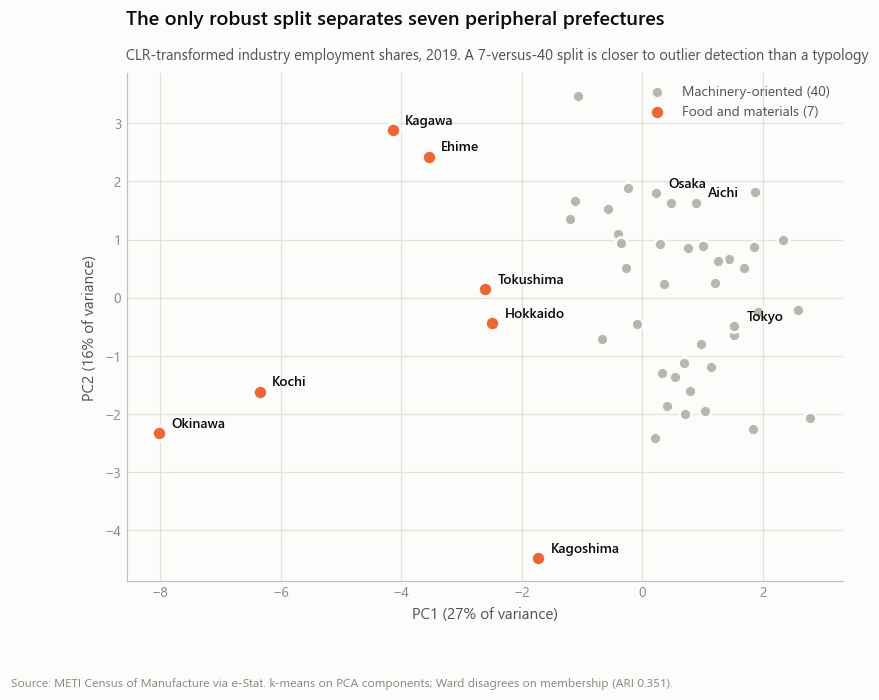

In [3]:
shares = share_matrix(2019)
coords, pca = reduce_dims(clr(shares)[0])
labels = cluster_labels(coords, rep["k_best"])["kmeans"]

pref_ja = {c: n for c, n in zip(shares.index, shares.index)}
cells = pd.read_csv(PROJ / "processed_data" / "manufacturing_2019_table3-01.csv",
                    dtype={"prefecture_code": str})
name_by_code = cells.drop_duplicates("prefecture_code").set_index("prefecture_code")["prefecture_name"]
romaji = [ROMAJI.get(name_by_code.get(c, ""), c) for c in shares.index]

fig, ax = plt.subplots(figsize=(8.4, 6.0))
small = labels == pd.Series(labels).value_counts().idxmin()
ax.scatter(coords[~small, 0], coords[~small, 1], s=62, color=GRAY_MARK,
           edgecolor=SURFACE, linewidth=1.8, zorder=3, label="Machinery-oriented (40)")
ax.scatter(coords[small, 0], coords[small, 1], s=86, color=ORANGE,
           edgecolor=SURFACE, linewidth=1.8, zorder=4, label="Food and materials (7)")
for i, nm in enumerate(romaji):
    if small[i] or nm in ("Aichi", "Tokyo", "Osaka"):
        ax.annotate(nm, (coords[i, 0], coords[i, 1]), textcoords="offset points",
                    xytext=(8, 4), fontsize=9, color=INK, fontweight="semibold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.legend(loc="best")
ax.set_title("The only robust split separates seven peripheral prefectures")
subtitle(ax, "CLR-transformed industry employment shares, 2019. "
             "A 7-versus-40 split is closer to outlier detection than a typology")
source_note(fig, "Source: METI Census of Manufacture via e-Stat. k-means on PCA "
                 "components; Ward disagrees on membership (ARI 0.351).")
fig.savefig(OUT / "chart9_prefecture_typology.png")
plt.show()

In [4]:
print("What separates the two groups (share difference from the national mean):")
for g in rep["cluster_profiles"]:
    over = ", ".join(INDUSTRY_EN.get(i, i) for i in g["over_represented"])
    under = ", ".join(INDUSTRY_EN.get(i, i) for i in g["under_represented"])
    print(f"\n  cluster {g['cluster']} — {g['n_prefectures']} prefectures")
    print(f"    over-represented : {over}")
    print(f"    under-represented: {under}")

members = [ROMAJI.get(name_by_code.get(c, ""), c)
           for c, l in rep["cluster_membership"].items() if l == int(small.argmax() and 0 or labels[small.argmax()])]
print("\nSmaller cluster membership:",
      ", ".join(sorted(ROMAJI.get(name_by_code.get(c, ""), c)
                       for c, l in rep["cluster_membership"].items()
                       if l == labels[list(shares.index).index(shares.index[small][0])])))

What separates the two groups (share difference from the national mean):

  cluster 0 — 7 prefectures
    over-represented : Food, Pulp & paper, Ceramics & stone
    under-represented: Business machinery, Transport equipment

  cluster 1 — 40 prefectures
    over-represented : Transport equipment, Business machinery, Production machinery
    under-represented: Pulp & paper, Food

Smaller cluster membership: Ehime, Hokkaido, Kagawa, Kagoshima, Kochi, Okinawa, Tokushima


## Conclusion

**The typology is not supported as a typology.** It passes two of three criteria and
fails algorithm agreement, and what it finds is a 7-versus-40 split rather than a set
of industrial types.

The seven — Hokkaido, the four Shikoku prefectures, Kagoshima and Okinawa — are
peripheral regions weighted toward food processing, pulp and paper, and ceramics, and
away from machinery. That is a real and interpretable pattern, but it is better
described as **one group of outliers against a broad industrial mainstream** than as a
classification of Japanese manufacturing.

The practical implication: **do not use cluster membership as a variable in later
analysis.** A partition two algorithms cannot agree on will not support anything built
on top of it.

### What would strengthen this

Clustering the **industries** rather than the prefectures. There are 24 industries
observed across 47 prefectures each, so co-location correlations rest on 47
observations per pair rather than 47 objects in 24 dimensions. That is the
Delgado, Porter and Stern approach
([NBER w20375](https://www.nber.org/papers/w20375)) and it is far better suited to
this data shape. See `docs/concepts.md` §7.